# Método del Disparo (Shooting Method)

## Introducción

El **método del disparo** es una técnica numérica utilizada para resolver **Problemas de Valor en la Frontera (PVF)**. Su objetivo es transformar un problema con condiciones en dos extremos del intervalo en un **Problema de Valor Inicial (PVI)**, el cual puede resolverse con métodos numéricos como Euler o Runge-Kutta.

El nombre "método del disparo" proviene de la analogía con lanzar un proyectil hacia un blanco: se realiza una estimación inicial y, si no se alcanza el objetivo, se corrige el "disparo" hasta obtener el resultado deseado.

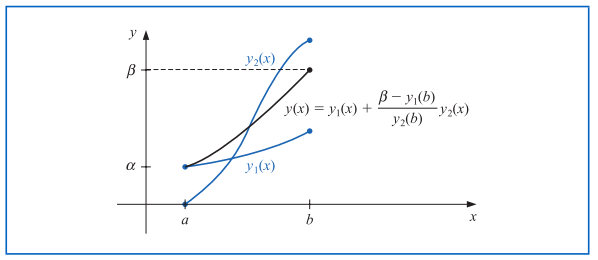
---

## Fundamento del método

Considere el siguiente problema de valor en la frontera:

$$
y'' = f(x,y,y'),
$$

con las condiciones:

$$
y(a)=\alpha,\qquad y(b)=\beta.
$$

Se conoce el valor de la función en ambos extremos, pero generalmente se desconoce la derivada inicial \(y'(a)\).

El método consiste en:

1. Suponer un valor inicial para la derivada desconocida \(y'(a)\).
2. Resolver el problema como un problema de valor inicial.
3. Comparar el valor obtenido en \(x=b\) con el valor requerido por la condición de frontera.
4. Ajustar la estimación inicial y repetir el proceso hasta que el error sea suficientemente pequeño.

---

## Transformación a un sistema de primer orden

Para aplicar el método, la ecuación diferencial de segundo orden se transforma en un sistema de primer orden.

Se definen las variables:

$$
y_1=y,
$$

$$
y_2=y'.
$$

Entonces el sistema queda:

$$
\begin{cases}
y_1'=y_2,\\
y_2'=f(x,y_1,y_2).
\end{cases}
$$

Las condiciones iniciales son:

$$
y_1(a)=\alpha,
$$

$$
y_2(a)=s,
$$

donde $s$ es la estimación de la derivada inicial.

---

## Algoritmo

1. Elegir un valor inicial para \(s\).
2. Resolver el sistema utilizando un método numérico (por ejemplo, Runge-Kutta de cuarto orden).
3. Calcular el valor obtenido en el extremo derecho del intervalo.
4. Comparar el resultado con la condición de frontera.
5. Si el error es grande, modificar el valor de \(s\).
6. Repetir el procedimiento hasta alcanzar la tolerancia establecida.

---

## Ejemplo

Resolver

$
y''=-y
$

con

$
y(0)=0,
$

$
y\left(\frac{\pi}{2}\right)=1.
$

Se transforma en

$
\begin{cases}
y_1'=y_2,\\
y_2'=-y_1.
\end{cases}
$

Se supone inicialmente

$
y_2(0)=0.8.
$

Después de resolver el sistema se verifica el valor obtenido en

$
x=\frac{\pi}{2}.
$

Si no se obtiene $y=1$, se ajusta la estimación de $y'(0)$ y se repite el procedimiento hasta cumplir la condición de frontera.

---

## Ventajas

- Fácil de implementar.
- Permite utilizar métodos conocidos para problemas de valor inicial.
- Ofrece buena precisión cuando la estimación inicial es adecuada.

---

## Desventajas

- Depende de una buena estimación inicial.
- Puede requerir varias iteraciones.
- En problemas muy sensibles puede no converger o converger a una solución incorrecta.

---
# Diferencia entre PVI y PVF

| Problema de Valor Inicial (PVI) | Problema de Valor en la Frontera (PVF) |
|---------------------------------|----------------------------------------|
| Condiciones en un solo punto | Condiciones en dos extremos |
| Se resuelve paso a paso | Se resuelve en todo el dominio |
| Utiliza métodos de Euler o Runge-Kutta | Utiliza diferencias finitas, disparo, elementos finitos |

---
## Aplicaciones

- Transferencia de calor.
- Diseño de vigas y estructuras.
- Vibraciones mecánicas.
- Mecánica de fluidos.
- Problemas de difusión y transporte.


# Método del Disparo usando el Método de Euler

## Resolución numérica con el método de Euler

El método del disparo puede implementarse utilizando el **método de Euler** para resolver el problema de valor inicial generado en cada iteración.

### Problema

Considere el siguiente problema de valor en la frontera:

$$
y''=-y
$$

con las condiciones

$$
y(0)=0,\qquad y\left(\frac{\pi}{2}\right)=1.
$$

Como la derivada inicial es desconocida, se supone un valor inicial

$$
y'(0)=s.
$$

---

## Paso 1. Convertir a un sistema de primer orden

Se definen las variables

$$
y_1=y,
$$

$$
y_2=y'.
$$

El sistema queda

$$
\begin{cases}
y_1'=y_2,\\
y_2'=-y_1.
\end{cases}
$$

Las condiciones iniciales son

$$
y_1(0)=0,\qquad y_2(0)=s.
$$

---

## Paso 2. Aplicar el método de Euler

Sea $h$ el tamaño del paso.

Las ecuaciones de Euler son

$$
y_{1,i+1}=y_{1,i}+h\,y_{2,i},
$$

$$
y_{2,i+1}=y_{2,i}+h(-y_{1,i}).
$$

o equivalentemente,

$$
y_{2,i+1}=y_{2,i}-h\,y_{1,i}.
$$

Estas ecuaciones permiten obtener una aproximación de la solución en cada punto del intervalo.

---

## Paso 3. Elegir una estimación inicial

Se toma una estimación para la pendiente inicial

$$
s=0.8.
$$

Además, se considera

$$
h=\frac{\pi/2}{10}\approx0.1571.
$$

Con estos datos se realizan diez iteraciones del método de Euler hasta llegar a

$$
x=\frac{\pi}{2}.
$$

Al finalizar se obtiene un valor aproximado de

$$
y\left(\frac{\pi}{2}\right).
$$

Si este valor no coincide con la condición de frontera

$$
y\left(\frac{\pi}{2}\right)=1,
$$

se modifica el valor de $s$ y se repite el procedimiento.

---

In [5]:
## Implementación en Octave

clc;
clear;

a = 0;
b = pi/2; 
n = 10;
h = (b-a)/n;

s = 0.8;      % Estimación inicial de y'(0)

x = a;
y1 = 0;
y2 = s;

fprintf(' x\t\t y\n');
fprintf('%.4f\t %.6f\n',x,y1);

for i = 1:n
    y1_new = y1 + h*y2;
    y2_new = y2 - h*y1;

    x = x + h;
    y1 = y1_new;
    y2 = y2_new;

    fprintf('%.4f\t %.6f\n',x,y1);
end

fprintf('\nValor obtenido en la frontera: %.6f\n',y1);
fprintf('Valor esperado: 1\n');
fprintf('Error: %.6f\n',abs(1-y1));


 x		 y
0.0000	 0.000000
0.1571	 0.125664
0.3142	 0.251327
0.4712	 0.373890
0.6283	 0.490252
0.7854	 0.597389
0.9425	 0.692429
1.0996	 0.772729
1.2566	 0.835944
1.4137	 0.880092
1.5708	 0.903615

Valor obtenido en la frontera: 0.903615
Valor esperado: 1
Error: 0.096385


---

## Interpretación de los resultados

- Si el valor obtenido en la frontera es **menor que 1**, la estimación de la pendiente inicial $s$ debe aumentarse.
- Si el valor obtenido es **mayor que 1**, la estimación debe disminuirse.
- El procedimiento se repite hasta que el error sea suficientemente pequeño.

Este proceso iterativo de ajustar la pendiente inicial es la esencia del **método del disparo**.